
EXERCÍCIO 1 - XOR com 2 neurônios
[0.1 0.1] -> 0.011 (HUMANO) | real: 0
[0.9 0.1] -> 0.988 (ZUMBI) | real: 1
[0.1 0.9] -> 0.989 (ZUMBI) | real: 1
[0.9 0.9] -> 0.014 (HUMANO) | real: 0

Acertos: 4/4
Acurácia: 100.0%

EXERCÍCIO 1 - XOR com 4 neurônios
[0.1 0.1] -> 0.006 (HUMANO) | real: 0
[0.9 0.1] -> 0.989 (ZUMBI) | real: 1
[0.1 0.9] -> 0.990 (ZUMBI) | real: 1
[0.9 0.9] -> 0.015 (HUMANO) | real: 0

Acertos: 4/4
Acurácia: 100.0%

EXERCÍCIO 2 - XOR usando tanh
[0.1 0.1] -> 0.005 (HUMANO) | real: 0
[0.9 0.1] -> 0.994 (ZUMBI) | real: 1
[0.1 0.9] -> 0.500 (HUMANO) | real: 1
[0.9 0.9] -> 0.500 (ZUMBI) | real: 0

Acertos: 2/4
Acurácia: 50.0%

EXERCÍCIO 3 - Dataset combinado com 8 exemplos
[0.1 0.1] -> 0.003 (HUMANO) | real: 0
[0.9 0.1] -> 0.970 (ZUMBI) | real: 1
[0.1 0.9] -> 0.994 (ZUMBI) | real: 1
[0.9 0.9] -> 0.037 (HUMANO) | real: 0
[0.2 0.2] -> 0.011 (HUMANO) | real: 0
[0.8 0.2] -> 0.026 (HUMANO) | real: 0
[0.2 0.8] -> 0.998 (ZUMBI) | real: 1
[0.8 0.8] -> 0.962 (ZUMBI) | real: 1

Acertos:

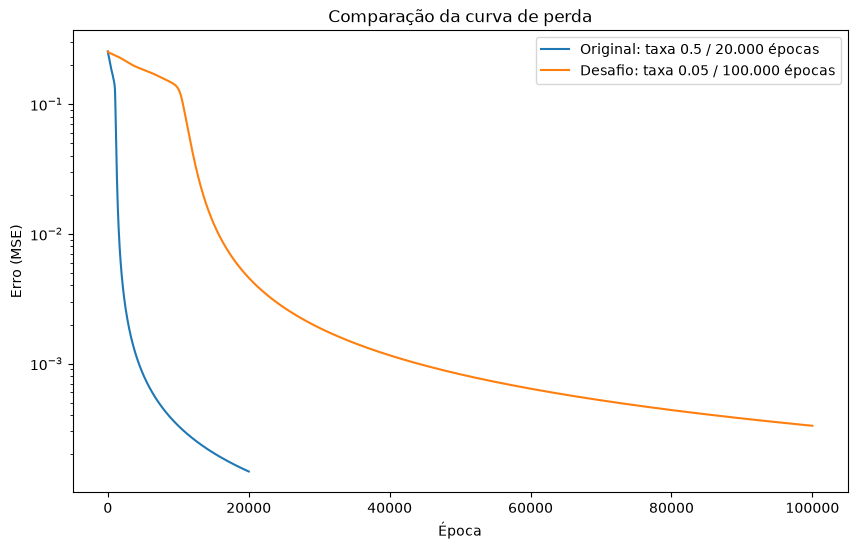


DESAFIO 5 - ESPAÇO OCULTO

Valores de h1 e h2:
Entrada [0.1 0.1] -> h1 = 0.9989, h2 = 0.9197
Entrada [0.9 0.1] -> h1 = 0.9079, h2 = 0.0289
Entrada [0.1 0.9] -> h1 = 0.9047, h2 = 0.0248
Entrada [0.9 0.9] -> h1 = 0.0929, h2 = 0.0001


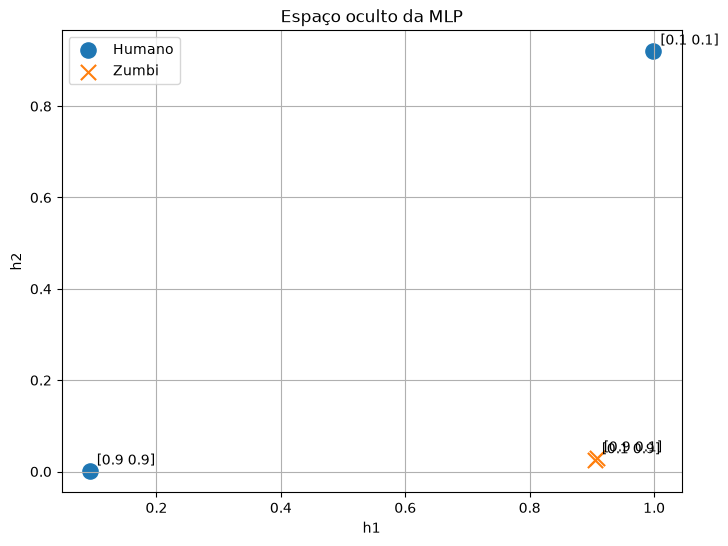

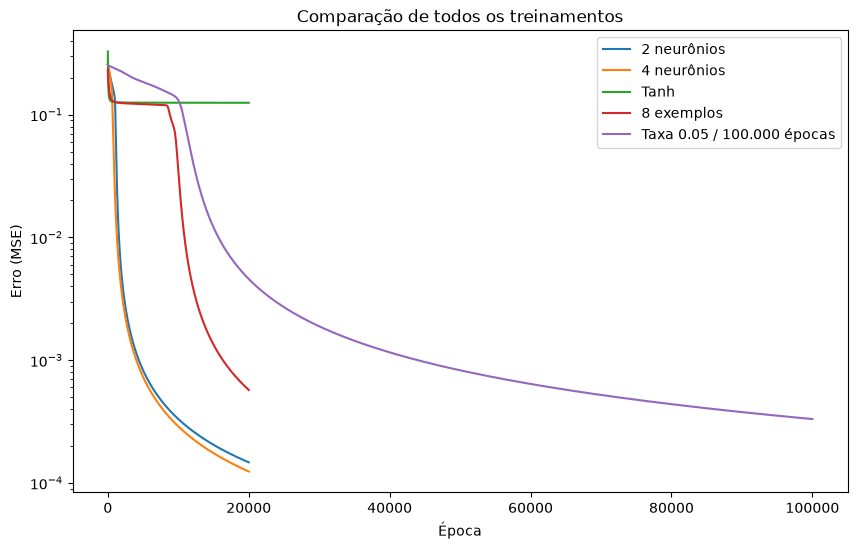


RESUMO DOS EXPERIMENTOS
Exercício 1 - 2 neurônios: perda = 0.000147
Exercício 1 - 4 neurônios: perda = 0.000124
Exercício 2 - Tanh: perda = 0.125062
Exercício 3 - 8 exemplos: perda = 0.000572
Desafio 4 - taxa 0.05: perda = 0.000331


In [3]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# FUNÇÕES DE ATIVAÇÃO
# ============================================================

def sigmoide(z):
    return 1 / (1 + np.exp(-z))


def sigmoide_derivada(a):
    return a * (1 - a)


def tanh(z):
    return np.tanh(z)


def tanh_derivada(a):
    return 1 - a ** 2


# ============================================================
# FORWARD
# ============================================================

def forward(X, W1, b1, W2, b2, ativacao="sigmoide"):

    z1 = np.dot(X, W1) + b1

    if ativacao == "tanh":
        h = tanh(z1)
    else:
        h = sigmoide(z1)

    z2 = np.dot(h, W2) + b2

    y_previsto = sigmoide(z2)

    return h, y_previsto


# ============================================================
# FUNÇÃO DE PERDA
# ============================================================

def calcular_perda(y_real, y_previsto):
    return np.mean((y_real - y_previsto) ** 2)


# ============================================================
# BACKWARD
# ============================================================

def backward(
    X,
    y,
    h,
    y_previsto,
    W2,
    ativacao="sigmoide"
):

    # Erro da saída
    erro_saida = (
        y_previsto - y
    ) * sigmoide_derivada(y_previsto)

    # Gradientes da saída
    dW2 = np.dot(h.T, erro_saida)

    db2 = np.sum(
        erro_saida,
        axis=0,
        keepdims=True
    )

    # Derivada da camada oculta
    if ativacao == "tanh":
        derivada_oculta = tanh_derivada(h)
    else:
        derivada_oculta = sigmoide_derivada(h)

    # Erro da camada oculta
    erro_oculta = (
        np.dot(erro_saida, W2.T)
        * derivada_oculta
    )

    # Gradientes da camada oculta
    dW1 = np.dot(
        X.T,
        erro_oculta
    )

    db1 = np.sum(
        erro_oculta,
        axis=0,
        keepdims=True
    )

    return dW1, db1, dW2, db2


# ============================================================
# FUNÇÃO PARA TREINAR A REDE
# ============================================================

def treinar_rede(
    X,
    y,
    n_oculta,
    ativacao="sigmoide",
    epocas=20000,
    taxa_aprendizagem=0.5
):

    np.random.seed(1)

    n_entrada = X.shape[1]
    n_saida = 1

    # Pesos da camada de entrada -> oculta
    W1 = np.random.randn(
        n_entrada,
        n_oculta
    )

    b1 = np.zeros(
        (1, n_oculta)
    )

    # Pesos da camada oculta -> saída
    W2 = np.random.randn(
        n_oculta,
        n_saida
    )

    b2 = np.zeros(
        (1, n_saida)
    )

    historico_perda = []

    # ========================================================
    # TREINAMENTO
    # ========================================================

    for epoca in range(epocas):

        # Forward
        h, y_previsto = forward(
            X,
            W1,
            b1,
            W2,
            b2,
            ativacao
        )

        # Calcula a perda
        perda = calcular_perda(
            y,
            y_previsto
        )

        historico_perda.append(perda)

        # Backward
        dW1, db1, dW2, db2 = backward(
            X,
            y,
            h,
            y_previsto,
            W2,
            ativacao
        )

        # Atualiza os pesos
        W2 -= taxa_aprendizagem * dW2
        b2 -= taxa_aprendizagem * db2

        W1 -= taxa_aprendizagem * dW1
        b1 -= taxa_aprendizagem * db1

    return (
        W1,
        b1,
        W2,
        b2,
        historico_perda
    )


# ============================================================
# MOSTRAR RESULTADOS
# ============================================================

def mostrar_resultados(
    nome,
    X,
    y,
    W1,
    b1,
    W2,
    b2,
    ativacao
):

    print("\n========================================")
    print(nome)
    print("========================================")

    _, y_final = forward(
        X,
        W1,
        b1,
        W2,
        b2,
        ativacao
    )

    acertos = 0

    for entrada, previsto, real in zip(
        X,
        y_final,
        y
    ):

        if previsto[0] >= 0.5:
            classe = "ZUMBI"
            classe_numero = 1
        else:
            classe = "HUMANO"
            classe_numero = 0

        if classe_numero == int(real[0]):
            acertos += 1

        print(
            f"{entrada} -> "
            f"{previsto[0]:.3f} "
            f"({classe}) | "
            f"real: {int(real[0])}"
        )

    acuracia = acertos / len(y) * 100

    print(
        f"\nAcertos: {acertos}/{len(y)}"
    )

    print(
        f"Acurácia: {acuracia:.1f}%"
    )


# ============================================================
# DATASET XOR
# ============================================================

X_XOR = np.array([
    [1, 1],
    [9, 1],
    [1, 9],
    [9, 9]
], dtype=float)

X_XOR = X_XOR / 10.0

y_XOR = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=float)


# ============================================================
# EXERCÍCIO 1
# XOR COM 2 NEURÔNIOS
# ============================================================

W1_1, b1_1, W2_1, b2_1, perda_1 = treinar_rede(
    X_XOR,
    y_XOR,
    n_oculta=2,
    ativacao="sigmoide",
    epocas=20000,
    taxa_aprendizagem=0.5
)

mostrar_resultados(
    "EXERCÍCIO 1 - XOR com 2 neurônios",
    X_XOR,
    y_XOR,
    W1_1,
    b1_1,
    W2_1,
    b2_1,
    "sigmoide"
)


# ============================================================
# EXERCÍCIO 1
# XOR COM 4 NEURÔNIOS
# ============================================================

W1_2, b1_2, W2_2, b2_2, perda_2 = treinar_rede(
    X_XOR,
    y_XOR,
    n_oculta=4,
    ativacao="sigmoide",
    epocas=20000,
    taxa_aprendizagem=0.5
)

mostrar_resultados(
    "EXERCÍCIO 1 - XOR com 4 neurônios",
    X_XOR,
    y_XOR,
    W1_2,
    b1_2,
    W2_2,
    b2_2,
    "sigmoide"
)


# ============================================================
# EXERCÍCIO 2
# XOR USANDO TANH
# ============================================================

W1_3, b1_3, W2_3, b2_3, perda_3 = treinar_rede(
    X_XOR,
    y_XOR,
    n_oculta=2,
    ativacao="tanh",
    epocas=20000,
    taxa_aprendizagem=0.5
)

mostrar_resultados(
    "EXERCÍCIO 2 - XOR usando tanh",
    X_XOR,
    y_XOR,
    W1_3,
    b1_3,
    W2_3,
    b2_3,
    "tanh"
)


# ============================================================
# EXERCÍCIO 3
# DATASET COMBINADO - 8 EXEMPLOS
# ============================================================

X_8 = np.array([

    # XOR
    [1, 1],
    [9, 1],
    [1, 9],
    [9, 9],

    # Aula 2
    [2, 2],
    [8, 2],
    [2, 8],
    [8, 8]

], dtype=float)

X_8 = X_8 / 10.0

y_8 = np.array([

    # XOR
    [0],
    [1],
    [1],
    [0],

    # Aula 2
    [0],
    [0],
    [1],
    [1]

], dtype=float)


W1_4, b1_4, W2_4, b2_4, perda_4 = treinar_rede(
    X_8,
    y_8,
    n_oculta=4,
    ativacao="sigmoide",
    epocas=20000,
    taxa_aprendizagem=0.5
)

mostrar_resultados(
    "EXERCÍCIO 3 - Dataset combinado com 8 exemplos",
    X_8,
    y_8,
    W1_4,
    b1_4,
    W2_4,
    b2_4,
    "sigmoide"
)


# ============================================================
# DESAFIO 4
# TAXA = 0.05
# ÉPOCAS = 100.000
# ============================================================

W1_5, b1_5, W2_5, b2_5, perda_5 = treinar_rede(
    X_XOR,
    y_XOR,
    n_oculta=2,
    ativacao="sigmoide",
    epocas=100000,
    taxa_aprendizagem=0.05
)

mostrar_resultados(
    "DESAFIO 4 - Taxa 0.05 e 100.000 épocas",
    X_XOR,
    y_XOR,
    W1_5,
    b1_5,
    W2_5,
    b2_5,
    "sigmoide"
)


# ============================================================
# GRÁFICO DO DESAFIO 4
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    perda_1,
    label="Original: taxa 0.5 / 20.000 épocas"
)

plt.plot(
    perda_5,
    label="Desafio: taxa 0.05 / 100.000 épocas"
)

plt.yscale("log")

plt.xlabel("Época")
plt.ylabel("Erro (MSE)")

plt.title(
    "Comparação da curva de perda"
)

plt.legend()

plt.show()


# ============================================================
# DESAFIO 5
# ESPAÇO OCULTO
# ============================================================

# Usamos a rede original com 2 neurônios
h_final, y_final = forward(
    X_XOR,
    W1_1,
    b1_1,
    W2_1,
    b2_1,
    "sigmoide"
)

print("\n========================================")
print("DESAFIO 5 - ESPAÇO OCULTO")
print("========================================")

print("\nValores de h1 e h2:")

for entrada, h in zip(X_XOR, h_final):

    print(
        f"Entrada {entrada} -> "
        f"h1 = {h[0]:.4f}, "
        f"h2 = {h[1]:.4f}"
    )


# ============================================================
# GRÁFICO DO ESPAÇO OCULTO
# ============================================================

plt.figure(figsize=(8, 6))

# Pontos humanos
indices_humano = y_XOR.ravel() == 0

plt.scatter(
    h_final[indices_humano, 0],
    h_final[indices_humano, 1],
    s=120,
    label="Humano"
)

# Pontos zumbis
indices_zumbi = y_XOR.ravel() == 1

plt.scatter(
    h_final[indices_zumbi, 0],
    h_final[indices_zumbi, 1],
    s=120,
    marker="x",
    label="Zumbi"
)

# Coloca o nome das entradas nos pontos
for i, entrada in enumerate(X_XOR):

    plt.annotate(
        f"{entrada}",
        (
            h_final[i, 0],
            h_final[i, 1]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("h1")
plt.ylabel("h2")

plt.title(
    "Espaço oculto da MLP"
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# GRÁFICO FINAL COMPARANDO TODOS OS TREINAMENTOS
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    perda_1,
    label="2 neurônios"
)

plt.plot(
    perda_2,
    label="4 neurônios"
)

plt.plot(
    perda_3,
    label="Tanh"
)

plt.plot(
    perda_4,
    label="8 exemplos"
)

plt.plot(
    perda_5,
    label="Taxa 0.05 / 100.000 épocas"
)

plt.yscale("log")

plt.xlabel("Época")
plt.ylabel("Erro (MSE)")

plt.title(
    "Comparação de todos os treinamentos"
)

plt.legend()

plt.show()


# ============================================================
# RESUMO FINAL
# ============================================================

print("\n========================================")
print("RESUMO DOS EXPERIMENTOS")
print("========================================")

print(
    f"Exercício 1 - 2 neurônios: "
    f"perda = {perda_1[-1]:.6f}"
)

print(
    f"Exercício 1 - 4 neurônios: "
    f"perda = {perda_2[-1]:.6f}"
)

print(
    f"Exercício 2 - Tanh: "
    f"perda = {perda_3[-1]:.6f}"
)

print(
    f"Exercício 3 - 8 exemplos: "
    f"perda = {perda_4[-1]:.6f}"
)

print(
    f"Desafio 4 - taxa 0.05: "
    f"perda = {perda_5[-1]:.6f}"
)